In [22]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
import pickle
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, cohen_kappa_score)

# Load Data
df = pd.read_csv("Crop Recommendation dataset(npk dataset 1).csv")
df.columns = df.columns.str.strip().str.lower()

In [14]:
df.head()

,n,p,k,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


Dataset Shape: (2200, 8)
Unique Crops: 22


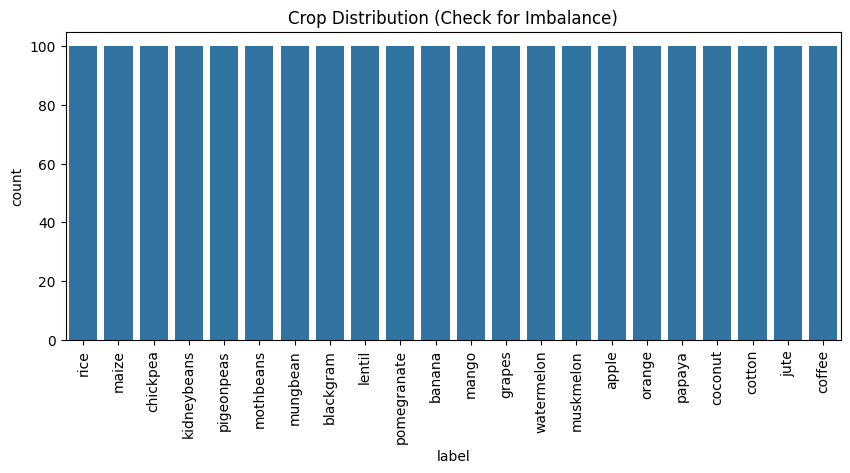

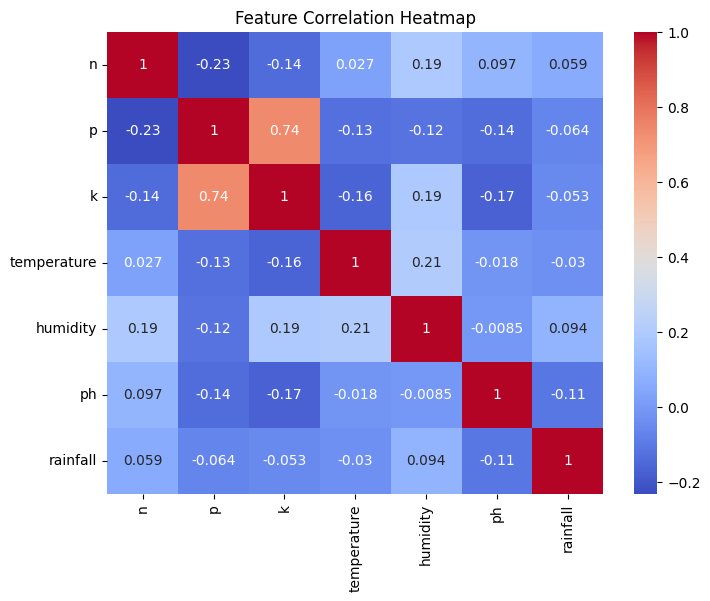

In [15]:
# EDA
print(f"Dataset Shape: {df.shape}")
print(f"Unique Crops: {df['label'].nunique()}")

plt.figure(figsize=(10, 4))
sns.countplot(x='label', data=df)
plt.xticks(rotation=90)
plt.title("Crop Distribution (Check for Imbalance)")
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(df.drop('label', axis=1).corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [16]:
# Data preparation and splitting 
# Separate Features and Target
X = df.drop('label', axis=1)
le = LabelEncoder()
y = le.fit_transform(df['label'])

# First Split: 70% Train, 30% Temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Second Split: 15% Val, 15% Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Training set:   {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Testing set:    {X_test.shape[0]} samples")

Training set:   1540 samples
Validation set: 330 samples
Testing set:    330 samples


In [23]:
results_list = []
trained_pipelines = {}

def evaluate_model(model_obj, name):
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model_obj)
    ])
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv)
    
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_val)
    
    results_list.append({
        "Model":            name,
        "CV Mean Acc (%)":  round(cv_scores.mean() * 100, 2),
        "CV Std Dev":       round(cv_scores.std(), 4),
        "Val Accuracy (%)": round(accuracy_score(y_val, preds) * 100, 2),
        "Precision":        round(precision_score(y_val, preds, average='weighted', zero_division=0), 4),
        "Recall":           round(recall_score(y_val, preds, average='weighted', zero_division=0), 4),
        "F1 Score":         round(f1_score(y_val, preds, average='weighted', zero_division=0), 4),
        "Kappa":            round(cohen_kappa_score(y_val, preds), 4),
    })
    
    trained_pipelines[name] = pipe

evaluate_model(LogisticRegression(max_iter=1000), "Logistic Regression")
evaluate_model(RandomForestClassifier(n_estimators=100, random_state=42), "Random Forest")
evaluate_model(SVC(kernel='linear'), "SVM (Linear)")
evaluate_model(SVC(kernel='rbf', probability=True), "SVM (RBF)")
evaluate_model(GaussianNB(), "Naive Bayes")
evaluate_model(KNeighborsClassifier(n_neighbors=5), "KNN")  # ← added

df_results = pd.DataFrame(results_list).sort_values(by="CV Mean Acc (%)", ascending=False).reset_index(drop=True)
display(df_results)

,Model,CV Mean Acc (%),CV Std Dev,Val Accuracy (%),Precision,Recall,F1 Score,Kappa
0,Random Forest,99.55,0.0033,99.09,0.9915,0.9909,0.9909,0.9905
1,Naive Bayes,99.48,0.0039,99.39,0.9943,0.9939,0.9939,0.9937
2,SVM (Linear),98.05,0.0092,98.79,0.9886,0.9879,0.9879,0.9873
3,SVM (RBF),97.53,0.0095,99.09,0.9918,0.9909,0.9909,0.9905
4,Logistic Regression,96.82,0.0063,96.67,0.9680,0.9667,0.9665,0.9651
5,KNN,96.43,0.0085,98.48,0.9861,0.9848,0.9848,0.9841


In [25]:
# Exporting the pipeline
# 1. Programmatically select the best model by CV accuracy
best_model_name = df_results.iloc[0]["Model"]
best_pipeline = trained_pipelines[best_model_name]
print(f"Best model: {best_model_name}")

# 2. Final unbiased evaluation on the held-out test set
test_preds = best_pipeline.predict(X_test)
print("\n--- Final Test Set Performance ---")
print(f"Accuracy  : {accuracy_score(y_test, test_preds) * 100:.2f}%")
print(f"Precision : {precision_score(y_test, test_preds, average='weighted', zero_division=0):.4f}")
print(f"Recall    : {recall_score(y_test, test_preds, average='weighted', zero_division=0):.4f}")
print(f"F1 Score  : {f1_score(y_test, test_preds, average='weighted', zero_division=0):.4f}")
print(f"Kappa     : {cohen_kappa_score(y_test, test_preds):.4f}")

# 3. Save the winning pipeline and label encoder
with open('agri_pipeline.pkl', 'wb') as f:
    pickle.dump(best_pipeline, f)

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("\n✅ Pipeline and LabelEncoder saved successfully.")

Best model: Random Forest

--- Final Test Set Performance ---
Accuracy  : 99.70%
Precision : 0.9972
Recall    : 0.9970
F1 Score  : 0.9970
Kappa     : 0.9968

✅ Pipeline and LabelEncoder saved successfully.


In [26]:
with open('agri_pipeline.pkl', 'rb') as f:
    loaded_pipeline = pickle.load(f)

with open('label_encoder.pkl', 'rb') as f:
    loaded_le = pickle.load(f)

def production_advisor():
    print("\n" + "="*40)
    print("OFFLINE AGRI-ADVISOR (PICKLE LOADED)")
    print("="*40)

    feature_names = ['n', 'p', 'k', 'temperature', 'humidity', 'ph', 'rainfall']
    user_inputs = []

    for feat in feature_names:
        raw = input(f"Enter {feat}: ")
        try:
            val = float(raw)
        except ValueError:
            print(f"Invalid input for '{feat}': expected a number, got '{raw}'.")
            return
        user_inputs.append(val)

    print("\n" + "-"*12 + " SUBMITTED DATA " + "-"*12)
    for name, value in zip(feature_names, user_inputs):
        print(f"{name.capitalize().ljust(12)}: {value}")
    print("-" * 40)

    user_df = pd.DataFrame([user_inputs], columns=feature_names)
    pred_idx = loaded_pipeline.predict(user_df)[0]
    prob = np.max(loaded_pipeline.predict_proba(user_df))
    crop_name = loaded_le.inverse_transform([pred_idx])[0]

    print(f"\nRECOMMENDED CROP: {crop_name.upper()}")
    print(f"CONFIDENCE: {prob*100:.2f}%")
    print("="*40)

production_advisor()


OFFLINE AGRI-ADVISOR (PICKLE LOADED)

------------ SUBMITTED DATA ------------
N           : 108.0
P           : 89.0
K           : 53.0
Temperature : 29.55
Humidity    : 78.07
Ph          : 5.81
Rainfall    : 99.34
----------------------------------------

RECOMMENDED CROP: BANANA
CONFIDENCE: 100.00%
